# 🟡 미션 2 — `√d_k` 로 나누는 이유를 직접 확인한다

논문 각주 4 는 이렇게 주장한다.
*성분이 평균 0·분산 1이면 `q·k` 의 분산은 `d_k` 다.*

**제출**
1. 그래프 2장 (`mission2-분산.png`, `mission2-포화.png`)
2. 한 줄: 나누지 않으면 무엇이 문제인가

In [1]:
import math
import sys

# 노트북(cwd=이 폴더)에서도, .py 를 상위에서 돌려도 attn/koplot 을 찾게 한다.
# ⚠️ __file__ 은 주피터 커널에 정의되지 않는다 — 노트북에서 NameError 로 죽는다.
sys.path[:0] = ["..", "."]

import matplotlib

# 노트북이면 그림이 셀 아래에 바로 뜬다. 터미널이면 화면 없이 파일로만 저장한다.
NOTEBOOK = "ipykernel" in sys.modules
if not NOTEBOOK:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import torch

import koplot

koplot.use_korean()
torch.manual_seed(0)

[koplot] 한글 폰트 적용: Noto Sans KR


## 1. 먼저 예측한다

`d_k` 를 4배로 키우면 `q·k` 의 흩어짐(분산)은 몇 배가 될까?
답을 **적어 두고** 다음 칸을 실행한다.

In [2]:
# TODO: 내 예측 — 몇 배?
내예측 = "___배"
print("내 예측:", 내예측)

내 예측: ___배


## 2. 재어 본다

In [3]:
차원들 = [2, 4, 8, 16, 32, 64, 128, 256, 512]
분산들 = []

for d_k in 차원들:
    q = torch.randn(20000, d_k)
    k = torch.randn(20000, d_k)
    분산들.append((q * k).sum(-1).var().item())     # q·k 를 2만 번 뽑아 분산

print(f"{'d_k':>6} | {'실측 분산':>12} | {'논문 주장':>10}")
print("-" * 34)
for d_k, v in zip(차원들, 분산들):
    print(f"{d_k:>6} | {v:>12.2f} | {d_k:>10}")

   d_k |        실측 분산 |      논문 주장
----------------------------------
     2 |         2.00 |          2
     4 |         4.02 |          4
     8 |         8.04 |          8
    16 |        15.87 |         16
    32 |        32.03 |         32
    64 |        62.88 |         64
   128 |       125.83 |        128
   256 |       254.17 |        256
   512 |       516.60 |        512


findfont: Failed to find font weight normal, now using 100.
findfont: Failed to find font weight normal, now using 100.
findfont: Failed to find font weight normal, now using 100.
findfont: Failed to find font weight normal, now using 100.


저장: mission2-분산.png


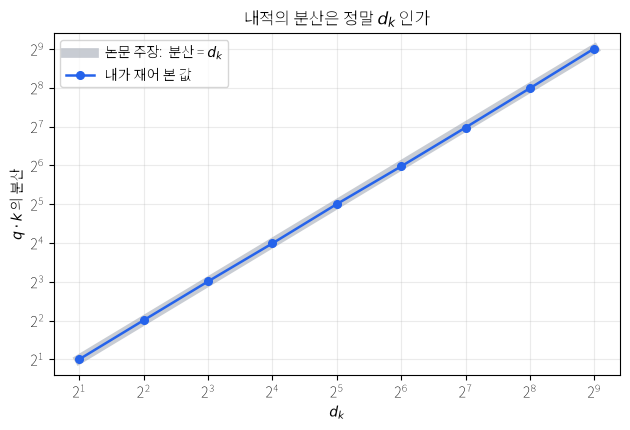

In [4]:
plt.figure(figsize=(6.4, 4.4))
plt.plot(차원들, 차원들, "-", color="#9ca3af", lw=7, alpha=0.55, label="논문 주장:  분산 = $d_k$")
plt.plot(차원들, 분산들, "o-", color="#2563eb", lw=1.8, ms=5.5, label="내가 재어 본 값")
plt.xscale("log", base=2)
plt.yscale("log", base=2)
plt.xlabel("$d_k$")
plt.ylabel("$q \\cdot k$ 의 분산")
plt.title("내적의 분산은 정말 $d_k$ 인가")
plt.legend()
plt.grid(alpha=0.25, which="both")
plt.tight_layout()
plt.savefig("mission2-분산.png", dpi=150)
if not NOTEBOOK:
    plt.close()                # 노트북에서는 닫지 않는다 — 닫으면 셀에 안 보인다
print("저장: mission2-분산.png")

## 3. 커지면 무엇이 나쁜가

분산이 크다는 것은 점수들이 멀리 벌어져 있다는 뜻이다.
그 상태로 softmax 를 통과시키면 어떻게 되는지 본다.

In [5]:
반복 = 3000
안나눔, 나눔 = [], []

for d_k in 차원들:
    q = torch.randn(반복, 1, d_k)
    k = torch.randn(반복, 8, d_k)                    # 자리 8곳에 점수를 매긴다
    s = (q @ k.transpose(1, 2)).squeeze(1)
    안나눔.append(torch.softmax(s, -1).max(-1).values.mean().item())
    나눔.append(torch.softmax(s / math.sqrt(d_k), -1).max(-1).values.mean().item())

print(f"{'d_k':>6} | {'안 나누면':>12} | {'√d_k 로 나누면':>16}")
print("-" * 42)
for d_k, a, b in zip(차원들, 안나눔, 나눔):
    print(f"{d_k:>6} | {a:>12.4f} | {b:>16.4f}")

   d_k |        안 나누면 |       √d_k 로 나누면
------------------------------------------
     2 |       0.4005 |           0.3243
     4 |       0.5316 |           0.3457
     8 |       0.6515 |           0.3563
    16 |       0.7461 |           0.3543
    32 |       0.8250 |           0.3638
    64 |       0.8790 |           0.3642
   128 |       0.9085 |           0.3599
   256 |       0.9365 |           0.3601
   512 |       0.9553 |           0.3571


저장: mission2-포화.png


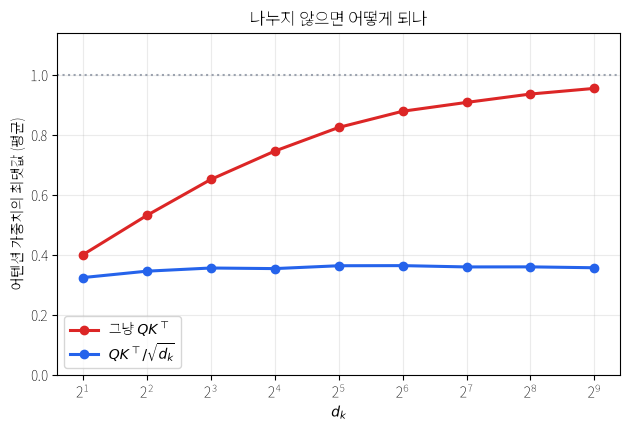

In [6]:
plt.figure(figsize=(6.4, 4.4))
plt.plot(차원들, 안나눔, "o-", color="#dc2626", lw=2.2, ms=6, label="그냥 $QK^\\top$")
plt.plot(차원들, 나눔, "o-", color="#2563eb", lw=2.2, ms=6, label="$QK^\\top/\\sqrt{d_k}$")
plt.axhline(1.0, color="#9ca3af", ls=":", lw=1.5)
plt.xscale("log", base=2)
plt.ylim(0, 1.14)
plt.xlabel("$d_k$")
plt.ylabel("어텐션 가중치의 최댓값 (평균)")
plt.title("나누지 않으면 어떻게 되나")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("mission2-포화.png", dpi=150)
if not NOTEBOOK:
    plt.close()
print("저장: mission2-포화.png")

## 4. 한 줄로 정리한다

최댓값이 1에 가까워진다는 것은 **한 자리에 전부 쏠리고 나머지는 0** 이라는 뜻이다.
그러면 나머지 자리로 가는 기울기가 거의 0이라 학습이 진행되지 않는다.

In [7]:
# TODO: 내 말로 한 줄
print("나누지 않으면: ______________________________________")

나누지 않으면: ______________________________________
